# 12.2.1 收益矩阵与复制动态

## 学习目标与先修知识

从相遇收益推导频率变化并核对边界平衡（equilibrium）。

先修：2.3 变化率与平衡；12.1 个体状态（state）；概率（probability）加权平均。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两类细胞在相遇时取得不同收益。若类型0目前占 p，如何从相遇收益写出类型0频率的变化，而不把收益误作繁殖概率？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先按对方类型比例计算两类平均收益，再计算总体平均收益。

In [2]:
p=.25;f0=p*3+(1-p)*0;f1=p*4+(1-p)*1;mean=p*f0+(1-p)*f1
print('p=0.25 时收益 f0、f1、平均及频率导数：',f0,f1,mean,p*(f0-mean))

p=0.25 时收益 f0、f1、平均及频率导数： 0.75 1.75 1.5 -0.1875


## 模型假设

收益矩阵（payoff matrix）是人工相遇模型（model），连续时间、充分混合、种群频率可连续变化；类型0频率 p、类型1频率1−p。本节把收益表的数值解释为相对适合度率（fitness rate），单位 1/T；它是教学增长率代理，不是任意效用分数或有限个体的生育概率。复制动态（replicator dynamics）据此表示相对率差与频率变化。

## 数学解释与推导

$f_0(p)=pM_{00}+(1-p)M_{01}$，$f_1(p)=pM_{10}+(1-p)M_{11}$，$\bar f=pf_0+(1-p)f_1$。定义 $\dot p=p(f_0-\bar f)=p(1-p)(f_0-f_1)$，故 $p=0,1$ 是边界不变点；内部等收益点也使导数（derivative）为0，但其稳定性要看附近符号。这里的率可为负，表示相对增长劣势；若要构造有限个体繁殖概率，必须另设合法映射。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def payoff_and_replicator(matrix, p):
    """Type 0 frequency p, type 1 frequency 1-p."""
    f0 = p * matrix[0][0] + (1 - p) * matrix[0][1]
    f1 = p * matrix[1][0] + (1 - p) * matrix[1][1]
    mean = p * f0 + (1 - p) * f1
    return [f0, f1, mean, p * (f0 - mean)]


def replicator_run(matrix, p0, dt, steps):
    history = [float(p0)]
    for _ in range(steps):
        p = history[-1]
        history.append(p + dt * payoff_and_replicator(matrix, p)[3])
    return history

## 对照实验

用固定收益表比较两类收益和频率方向，再从两个初始频率做细步长轨迹（trajectory）。

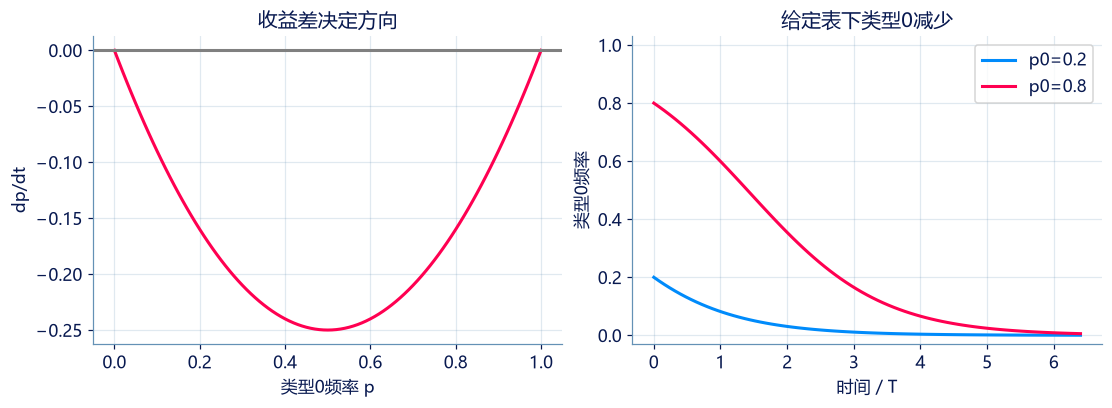

In [4]:
M=[[3.,0.],[4.,1.]]
grid=np.linspace(0,1,101)
rates=np.array([payoff_and_replicator(M,float(p))[3] for p in grid])
paths={p0:replicator_run(M,p0,.08,80) for p0 in [.2,.8]}
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].plot(grid,rates,color=PINK);axes[0].axhline(0,color='gray')
axes[0].set(xlabel='类型0频率 p',ylabel='dp/dt',title='收益差决定方向')
for p0,path in paths.items():axes[1].plot(np.arange(len(path))*.08,path,label=f'p0={p0}')
axes[1].set(xlabel='时间 / T',ylabel='类型0频率',ylim=(-.03,1.03),title='给定表下类型0减少')
axes[1].legend();plt.show()

## 结果解释

这张表中类型1始终比类型0高1/T，因此内部频率导数为负。图只说明该教学收益表及充分混合假设下的方向，不证明真实合作总会下降。

### 独立核对

独立核对代数恒等式、边界导数、两收益相同时的导数。

In [5]:
for p in [0.,.25,.5,.75,1.]:
    f0,f1,mean,rate=payoff_and_replicator(M,p)
    np.testing.assert_allclose(rate,p*(1-p)*(f0-f1))
    np.testing.assert_allclose(mean,p*f0+(1-p)*f1)
assert payoff_and_replicator(M,0.)[3]==payoff_and_replicator(M,1.)[3]==0.
assert all(0<=v<=1 for path in paths.values() for v in path)
print('收益恒等式、频率边界与细步长轨迹通过。')

收益恒等式、频率边界与细步长轨迹通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：由收益计算复制动态

类型0频率 p，类型1频率1−p；matrix[row][column] 是行类型与列类型相遇的收益。分别计算 f0、f1、平均收益和连续时间 dp/dt=p(f0−平均收益)。本题把收益数值解释为相对适合度率（fitness rate），单位1/T；它可为负数，但不是繁殖概率（probability）或任意效用分数。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    p: float,
) -> tuple[float, float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 2×2 行对列收益。 | 1/T |
| `p` | `float` | 类型0频率，0≤p≤1。 | 1 |

**返回值**

按以下顺序返回元组：(f0, f1, mean, dpdt)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `f0` | `float` | 类型0平均收益。 | 1/T |
| `f1` | `float` | 类型1平均收益。 | 1/T |
| `mean` | `float` | 种群平均收益。 | 1/T |
| `dpdt` | `float` | 类型0频率变化率。 | 1/T |

**计算规则**

f0=p·M00+(1−p)·M01，f1=p·M10+(1−p)·M11；dp/dt=p(1−p)(f0−f1)。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 2×2 行对列收益。 | [[3.0, 0.0], [4.0, 1.0]] | 1/T |
| p | 类型0频率，0≤p≤1。 | 0.25 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[3.0, 0.0], [4.0, 1.0]]
p = 0.25

result = solve(matrix, p)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| f0 | 类型0平均收益。 | 0.75 | 1/T |
| f1 | 类型1平均收益。 | 1.75 | 1/T |
| mean | 种群平均收益。 | 1.5 | 1/T |
| dpdt | 类型0频率变化率。 | -0.1875 | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.75, 1.75, 1.5, -0.1875)
```

**样例解释**

平均收益按两类频率加权；p=0 或 p=1 时两类型方程的边界不被推出区间。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：由收益计算复制动态](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-payoff-replicator)

### 第 2 题 · 单项选择题：p(1−p) 从哪里来

两类型收益为 f0、f1，平均收益 pf0+(1−p)f1。dp/dt 等价于什么？

- **A.** p(1−p)(f0−f1)。
- **B.** p(f0+f1)。
- **C.** f0−f1，与 p 无关。
- **D.** (1−p)f0。

[作答：p(1−p) 从哪里来](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-replicator-factor)

### 第 3 题 · 单项选择题：收益不能直接当概率

收益矩阵（payoff matrix）里有负数。把收益直接当个体繁殖概率（probability）有何问题？

- **A.** 概率必须位于[0,1]，需另声明映射。
- **B.** 复制动态（replicator dynamics）完全不允许负收益。
- **C.** 负收益表示负数量后代。
- **D.** 收益数值总是临床效用。

[作答：收益不能直接当概率](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-payoff-not-birth)

### 第 4 题 · 单项选择题：内部不变点

若某个内部频率 p* 满足 f0(p*)=f1(p*)，该点的 dp/dt 为何？

- **A.** 0，但稳定性仍需看附近方向。
- **B.** 必为1。
- **C.** 一定全局稳定。
- **D.** 只能在 p=0 或1出现。

[作答：内部不变点](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-equal-payoff)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供博弈与合作的主题背景；本节方程由给定收益表直接推导。